In [6]:
#TODO: Explore nulls in country
#TODO: Explore month x week cancellation rate



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('viridis')
sns.set_context('notebook')

df_default = pd.read_csv('../data/hotel_bookings.csv')
display(df_default.shape)
df_default.describe(include='all')

(119390, 32)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [8]:
df_default.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [9]:
#printing share of null values per column
share_nulls = {}
n_rows = len(df_default)
for colname in df_default.columns:
    nulls_pctng = df_default[colname].isnull().sum()/n_rows*100
    if nulls_pctng>0:
        share_nulls[colname] = nulls_pctng

for colname,share_of_nulls in share_nulls.items():
     print(f'Column {colname} has null share of {share_nulls[colname]:.2f}%')

Column children has null share of 0.00%
Column country has null share of 0.41%
Column agent has null share of 13.69%
Column company has null share of 94.31%


In [10]:
df_default.children = df_default.children.fillna(0) #we assume na children = no children

df_default.country = df_default.country.fillna('Unknown') #swapping na country to "Unknown"

df_default.company = df_default.company.fillna('Unknown') #swapping na company to "Unknown"

df_default["arrival_date"] = pd.to_datetime(
    df_default["arrival_date_year"].astype(str) + " " +
    df_default["arrival_date_month"] + " " +
    df_default["arrival_date_day_of_month"].astype(str)) #constructing arrival date variable in YYYY-MM-DD format

df_default["arrival_date_year"] = df_default["arrival_date_year"].astype(int)

import calendar
month_order = list(calendar.month_name)[1:]
df_default['arrival_date_month'] = pd.Categorical(df_default['arrival_date_month'], categories=month_order, ordered=True)
df_default.sort_values('arrival_date', inplace=True)

df_default.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
75559,City Hotel,0,257,2015,July,27,1,0,2,1,...,6.0,Unknown,0,Transient,80.0,0,0,Check-Out,2015-07-03,2015-07-01
75560,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01
75561,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01
75562,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01


In [11]:
#reformatting column names for ease of use
for column in df_default.columns:
    df_default.rename(columns={column: column.replace('_', ' ').title().replace(' ', '')}, inplace=True)
df_default.columns

Index(['Hotel', 'IsCanceled', 'LeadTime', 'ArrivalDateYear',
       'ArrivalDateMonth', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth',
       'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Children',
       'Babies', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel',
       'IsRepeatedGuest', 'PreviousCancellations',
       'PreviousBookingsNotCanceled', 'ReservedRoomType', 'AssignedRoomType',
       'BookingChanges', 'DepositType', 'Agent', 'Company',
       'DaysInWaitingList', 'CustomerType', 'Adr', 'RequiredCarParkingSpaces',
       'TotalOfSpecialRequests', 'ReservationStatus', 'ReservationStatusDate',
       'ArrivalDate'],
      dtype='str')

In [12]:
df_default[(df_default.Adults == 0) & (df_default.Children == 0) & (df_default.Babies == 0)]

,Hotel,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,...,Agent,Company,DaysInWaitingList,CustomerType,Adr,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,ArrivalDate
40392,City Hotel,0,132,2015,July,30,23,2,5,0,...,1.0,Unknown,0,Transient-Party,0.00,0,0,Check-Out,2015-07-30,2015-07-23
76620,City Hotel,0,110,2015,July,30,25,2,2,0,...,17.0,Unknown,0,Transient-Party,0.00,0,0,Check-Out,2015-07-29,2015-07-25
40922,City Hotel,0,0,2015,August,33,9,2,0,0,...,9.0,Unknown,0,Contract,0.00,0,0,Check-Out,2015-08-11,2015-08-09
41020,City Hotel,0,0,2015,August,33,10,9,20,0,...,NaN,47.0,0,Transient,0.00,0,0,Check-Out,2015-09-08,2015-08-10
41056,City Hotel,0,0,2015,August,33,11,0,4,0,...,NaN,49.0,0,Transient-Party,0.00,0,1,Check-Out,2015-08-15,2015-08-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116251,City Hotel,0,44,2017,July,28,15,1,1,0,...,425.0,Unknown,0,Transient,73.80,0,0,Check-Out,2017-07-17,2017-07-15
116534,City Hotel,0,2,2017,July,28,15,2,5,0,...,9.0,Unknown,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22,2017-07-15
117087,City Hotel,0,170,2017,July,30,27,0,2,0,...,52.0,Unknown,0,Transient,0.00,0,0,Check-Out,2017-07-29,2017-07-27
72968,City Hotel,1,0,2017,August,32,11,0,0,0,...,NaN,Unknown,0,Transient,0.00,0,0,Canceled,2017-08-11,2017-08-11


In [13]:
df_default[(df_default.Adults == 0) & ((df_default.Children > 0) | (df_default.Babies>0)) & (df_default.ReservationStatus == 'Check-Out')][['Adults', 'Children', 'Babies', 'ReservationStatus']]

,Adults,Children,Babies,ReservationStatus
40984,0,3.0,0,Check-Out
41048,0,2.0,0,Check-Out
41446,0,2.0,0,Check-Out
41952,0,2.0,0,Check-Out
79596,0,2.0,0,Check-Out
...,...,...,...,...
117128,0,2.0,0,Check-Out
117303,0,2.0,0,Check-Out
117274,0,2.0,0,Check-Out
117453,0,2.0,0,Check-Out


<Axes: xlabel='ArrivalDateMonth', ylabel='IsCanceled'>

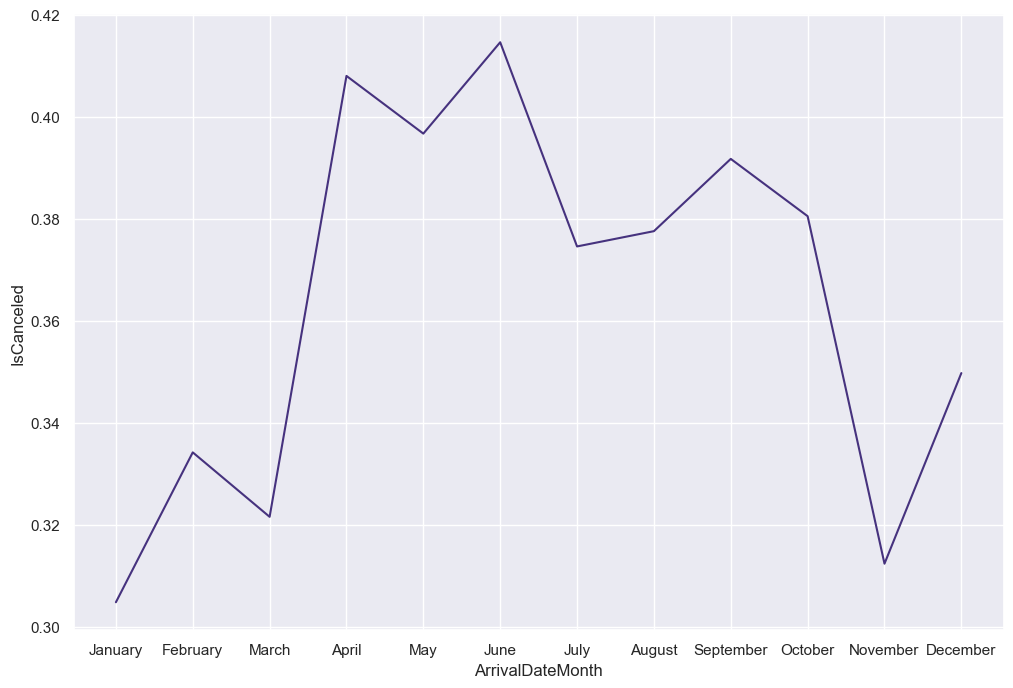

In [14]:
by_month = df_default.groupby('ArrivalDateMonth')['IsCanceled'].mean()
sns.lineplot(data=by_month)

In [15]:
df_default.ArrivalDateYear.describe()

count    119390.000000
mean       2016.156554
std           0.707476
min        2015.000000
25%        2016.000000
50%        2016.000000
75%        2017.000000
max        2017.000000
Name: ArrivalDateYear, dtype: float64